# JOIN SEVERAL CSV FILES INTO A SINGLE DATAFRAME THAT WE CAN ANALYZE AND WORK WITH

## Libraries

In [1]:
import sys
print(sys.executable)

/home/tim/OneDrive/fedora/Documents/SEMESTER4/int/werkstudent/N2-fixers-in-the-ocean/.venv/bin/python


In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import seaborn as sns
import joblib as joblib
from scipy.stats import gaussian_kde

## Functions

In [3]:
from visualize import plotColsOnMap, histCols, plotCorMatr
from format import filterDepth

## We load the data into the notebook
I want to use combined environmental data from the joined csv file as well as avg file to create the model.

In [4]:
cor_cols = ["LATITUDE","LONGITUDE"]

env_data = pd.read_csv("../csv/filled/env_data_lat_fill.csv")
bact_data = pd.read_csv("../csv/features/bact_data.csv")

#these are lists of all columns
env_cols = env_data.columns
bact_cols = bact_data.columns

#in order to easily refernce the columns we might need here they are stored as lists
env_cols_data = ['O2', 'T','N', 'P',"Fe", "solar","N:P"]
bact_cols_data = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']
bact_cols_data_short = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

print(env_cols)
print(bact_cols)
print(set(env_cols.intersection(set(bact_cols))))

Index(['LATITUDE', 'LONGITUDE', 'DEPTH (m)', 'O2', 'T', 'N', 'P', 'Fe',
       'solar', 'N:P'],
      dtype='object')
Index(['LATITUDE', 'LONGITUDE', 'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)', 'DEPTH (m)'],
      dtype='object')
{'DEPTH (m)', 'LONGITUDE', 'LATITUDE'}


## Properties of the initial data sets

In [5]:
env_data.head()

,LATITUDE,LONGITUDE,DEPTH (m),O2,T,N,P,Fe,solar,N:P
0,-78,-178,0,327.14557,-1.39071,19.783365,1.585354,0.236246,83.87408,12.478834
1,-78,-178,5,323.66098,-1.39741,19.997166,1.564636,0.236246,83.87408,12.780713
2,-78,-178,10,322.85922,-1.42181,20.630762,1.587365,0.236246,83.87408,12.996859
3,-78,-178,15,321.84424,-1.43271,20.905594,1.587337,0.236246,83.87408,13.170230
4,-78,-178,20,320.22778,-1.42881,20.937330,1.598962,0.236246,83.87408,13.094323


In [6]:
bact_data.head()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),DEPTH (m)
0,-9.0,-137.0,0.0,0.03,0.0,5.0
1,-12.0,-134.0,0.0,0.00,0.0,5.0
2,-13.0,-132.0,0.0,0.00,0.0,70.0
3,-15.0,-130.0,0.0,0.00,0.0,5.0
4,-17.0,-128.0,0.0,0.00,0.0,5.0


In [7]:
env_data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265844 entries, 0 to 3265843
Data columns (total 10 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   3265844 non-null  int64  
 1   LONGITUDE  3265844 non-null  int64  
 2   DEPTH (m)  3265844 non-null  int64  
 3   O2         3265844 non-null  float64
 4   T          3265844 non-null  float64
 5   N          3265844 non-null  float64
 6   P          3265844 non-null  float64
 7   Fe         3265844 non-null  float64
 8   solar      3265844 non-null  float64
 9   N:P        3265844 non-null  float64
dtypes: float64(7), int64(3)
memory usage: 249.2 MB


In [8]:
bact_data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7086 entries, 0 to 7085
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   7086 non-null   float64
 1   LONGITUDE                                  7086 non-null   float64
 2   Trichodesmium nifH Gene (x106 copies m-3)  5360 non-null   float64
 3   UCYN-A nifH Gene (x106 copies m-3)         5701 non-null   float64
 4   UCYN-B nifH Gene (x106 copies m-3)         5257 non-null   float64
 5   DEPTH (m)                                  7074 non-null   float64
dtypes: float64(6)
memory usage: 332.3 KB


In [9]:
bact_data.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),DEPTH (m)
count,7086.000000,7086.000000,5.360000e+03,5.701000e+03,5257.000000,7074.000000
mean,12.956675,-11.702653,4.251475e+04,5.411675e+03,997.270231,52.162044
std,22.717608,124.837486,2.642069e+06,1.224900e+05,23161.248901,82.371989
min,-76.000000,-180.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.000000,-153.000000,1.307500e-01,0.000000e+00,0.000000,5.000000
50%,18.000000,-35.000000,2.318500e+00,1.188000e+00,0.359000,25.000000
75%,23.000000,118.000000,3.558975e+01,3.354000e+01,5.435000,75.450000
max,120.000000,187.000000,1.900000e+08,4.810000e+06,898000.000000,1700.000000


## Joining them together
In order to concatenate the dataframes we need to set index to the coordinate columns.

In [10]:
#used pd merge
combined_df = pd.merge(bact_data, env_data, on=['LATITUDE', 'LONGITUDE',"DEPTH (m)"], how='left')
#combined_df = bact_data.join(env_data, on=['LATITUDE', 'LONGITUDE',"DEPTH (m)"])
combined_df.head()

/tmp/ipykernel_1326/1568924283.py:2: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  combined_df = pd.merge(bact_data, env_data, on=['LATITUDE', 'LONGITUDE',"DEPTH (m)"], how='left')


,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),DEPTH (m),O2,T,N,P,Fe,solar,N:P
0,-9.0,-137.0,0.0,0.03,0.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-12.0,-134.0,0.0,0.00,0.0,5.0,201.06654,27.456,1.126085,0.285271,0.0,181.83206,3.947422
2,-12.0,-134.0,0.0,0.00,0.0,5.0,201.06654,27.456,1.126085,0.285271,0.0,181.83206,3.947422
3,-12.0,-134.0,0.0,0.00,0.0,5.0,201.06654,27.456,1.126085,0.285271,0.0,181.83206,3.947422
4,-12.0,-134.0,0.0,0.00,0.0,5.0,201.06654,27.456,1.126085,0.285271,0.0,181.83206,3.947422


In [11]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33118 entries, 0 to 33117
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   33118 non-null  float64
 1   LONGITUDE                                  33118 non-null  float64
 2   Trichodesmium nifH Gene (x106 copies m-3)  28513 non-null  float64
 3   UCYN-A nifH Gene (x106 copies m-3)         27195 non-null  float64
 4   UCYN-B nifH Gene (x106 copies m-3)         24944 non-null  float64
 5   DEPTH (m)                                  33106 non-null  float64
 6   O2                                         26960 non-null  float64
 7   T                                          26960 non-null  float64
 8   N                                          26960 non-null  float64
 9   P                                          26960 non-null  float64
 10  Fe                    

## Map plots of resulting data
We know that the resulting set of points is the subset of environmental points from the inital dataset. So, I thought that we should see a clear picture of the data that we are going to be training on and keeping.

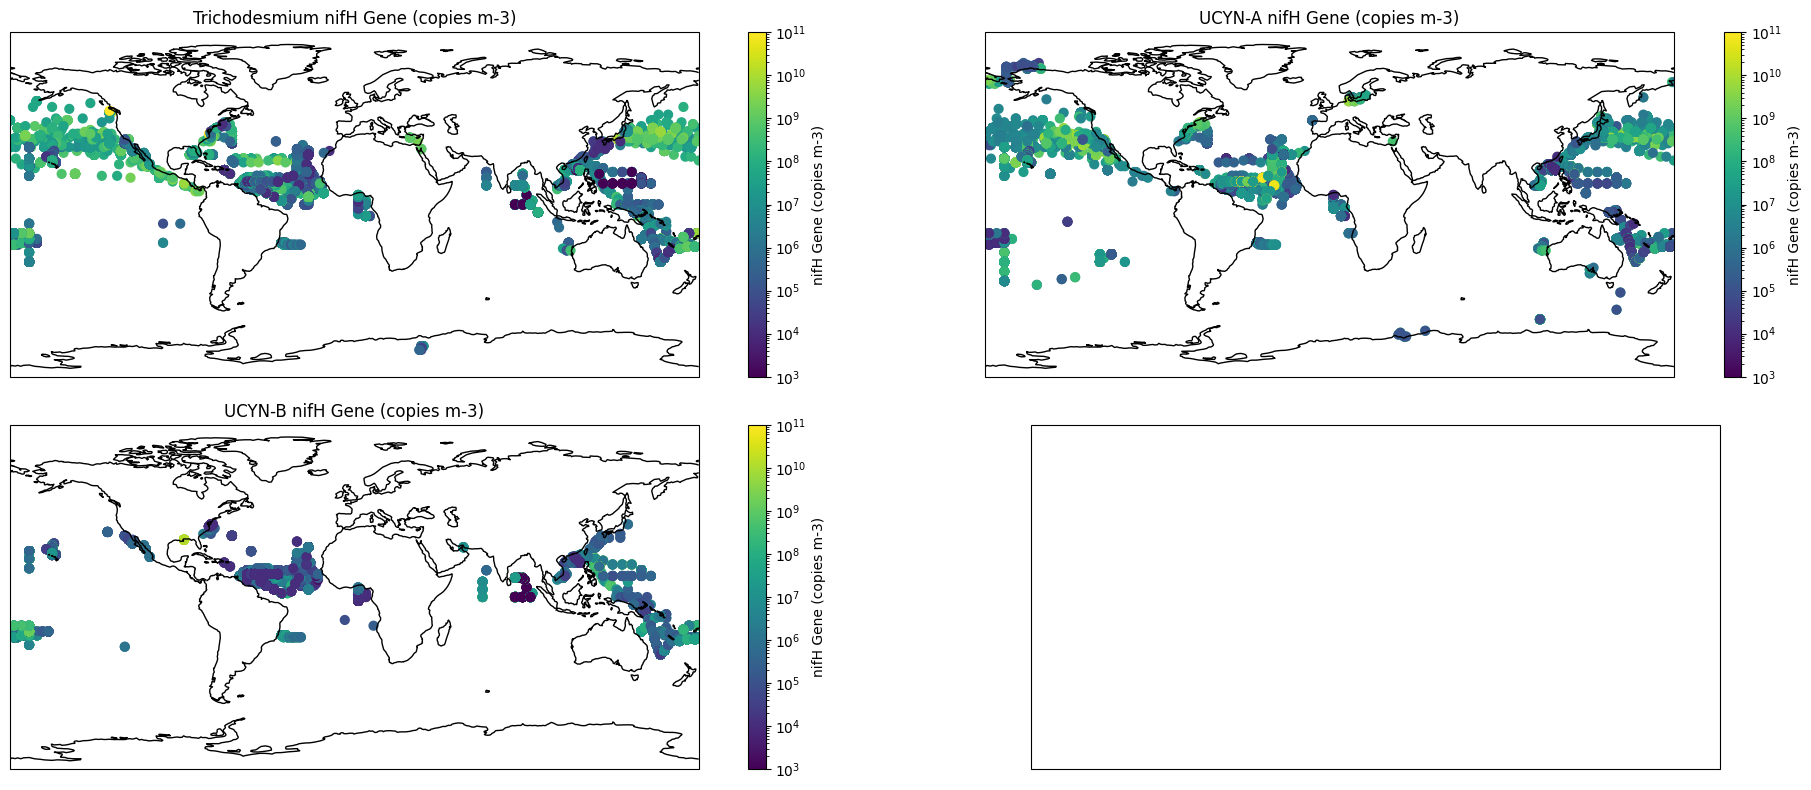

In [12]:
plotColsOnMap(bact_cols_data, combined_df, log_range=True)

Since, we basically performed an inner join and only kept the rows where the data is present for both datasets the environmental data kept is way more scarce, than the initial set. One key feature that stands out to me here is that it is moslty centered around the eqautor and the tropics, making any inference we get at the poles somewhat uncertain and likely inaccurate.

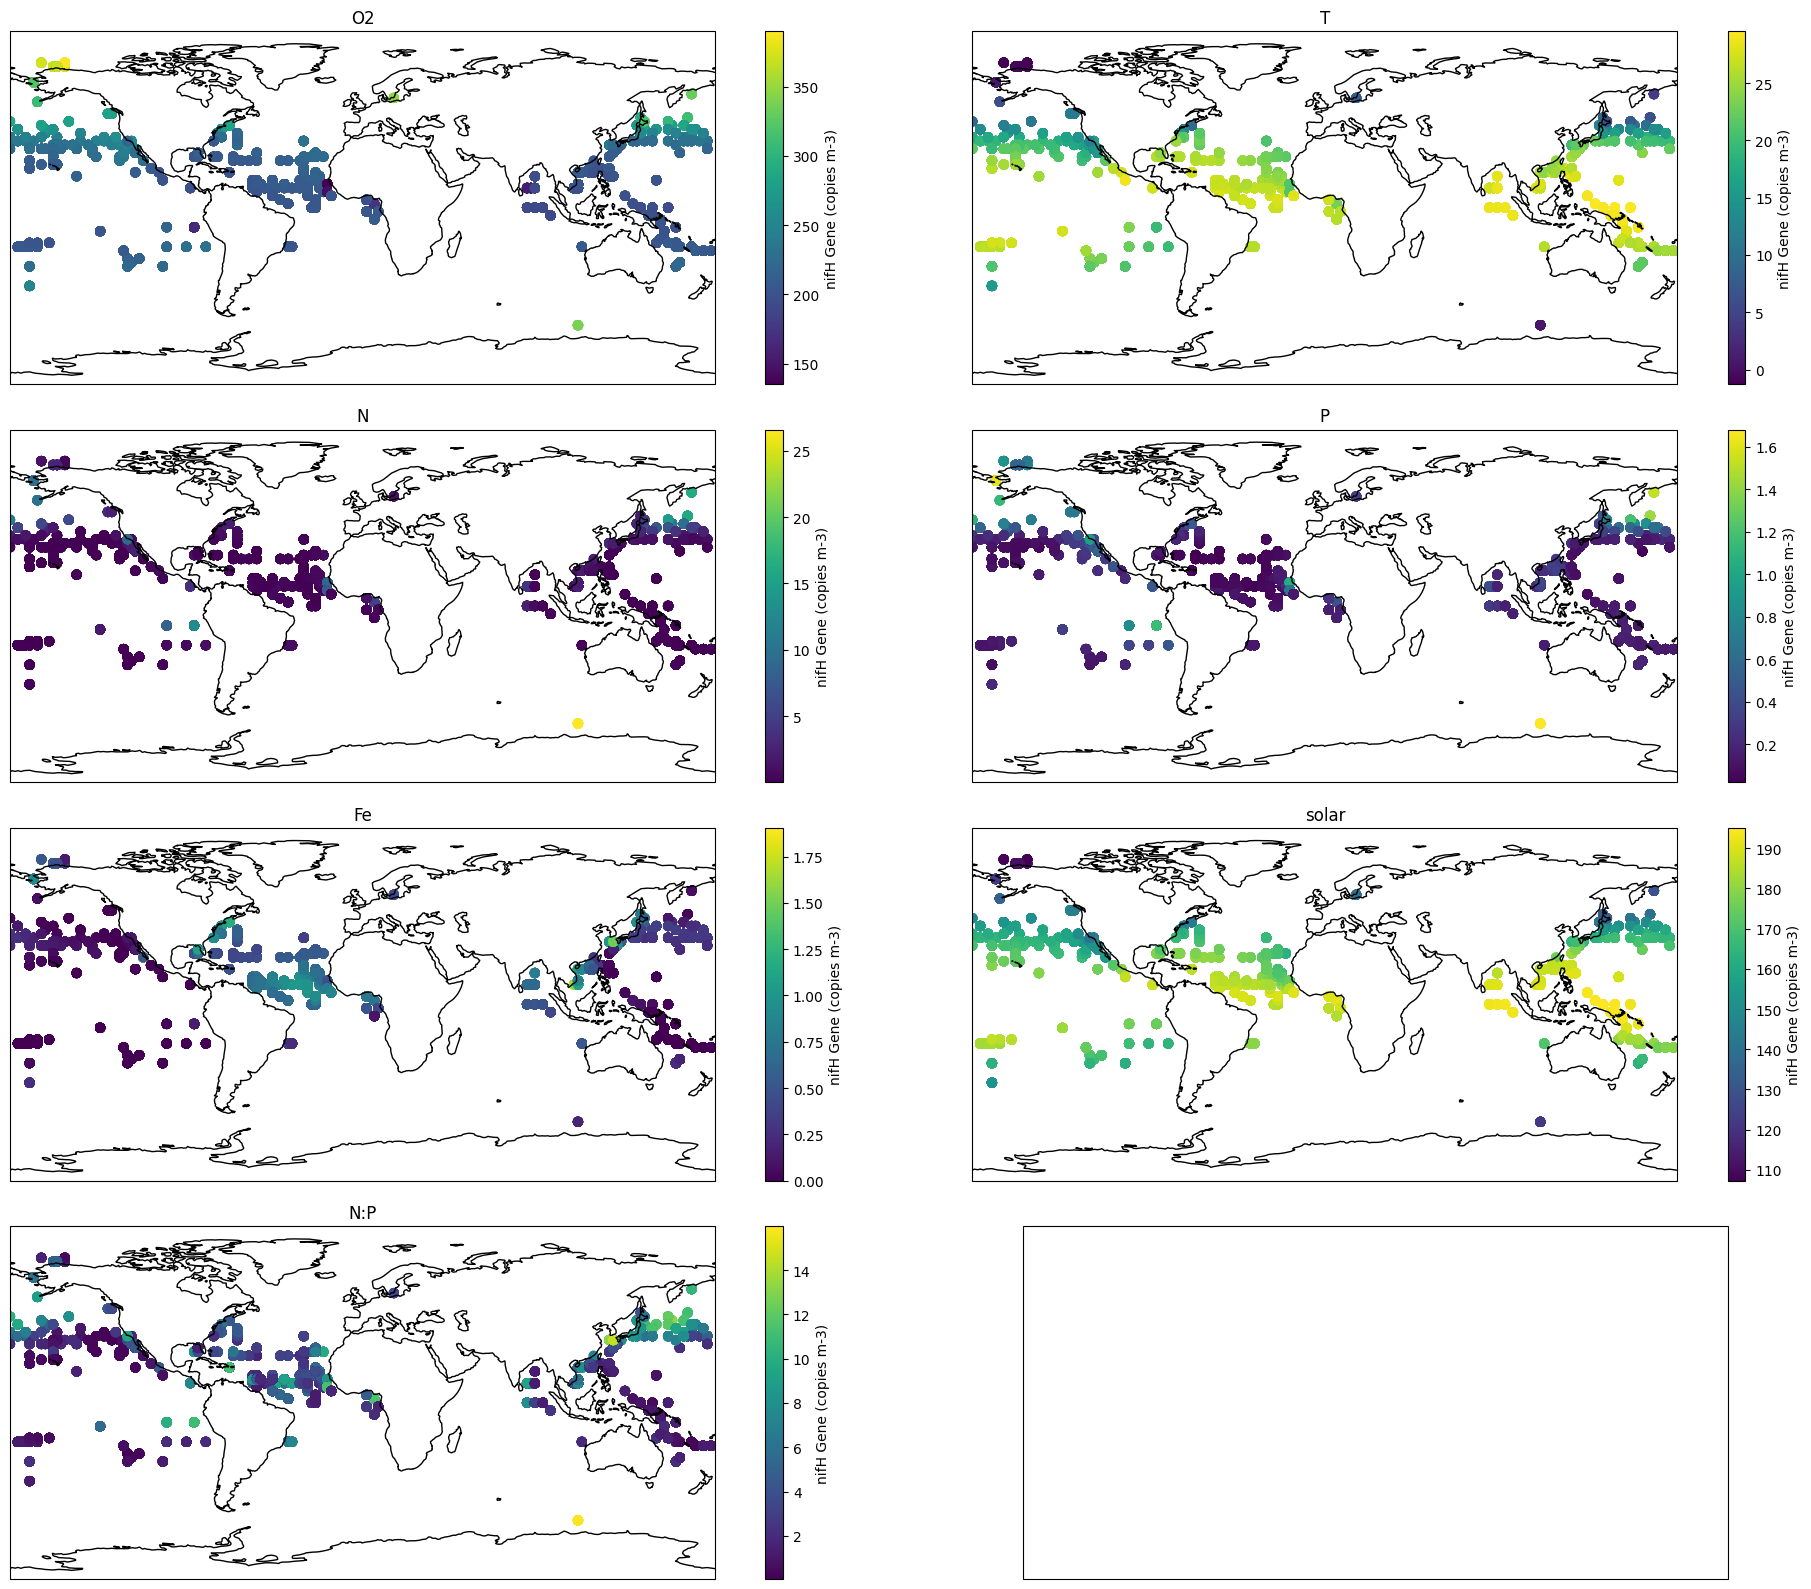

In [13]:
plotColsOnMap(env_cols_data, combined_df, constant = 1)

## Pairplot for values mentioned in the paper

This graph aims to replicate the pairplot graph from the paper that shows how distributions of values in relation to each other.

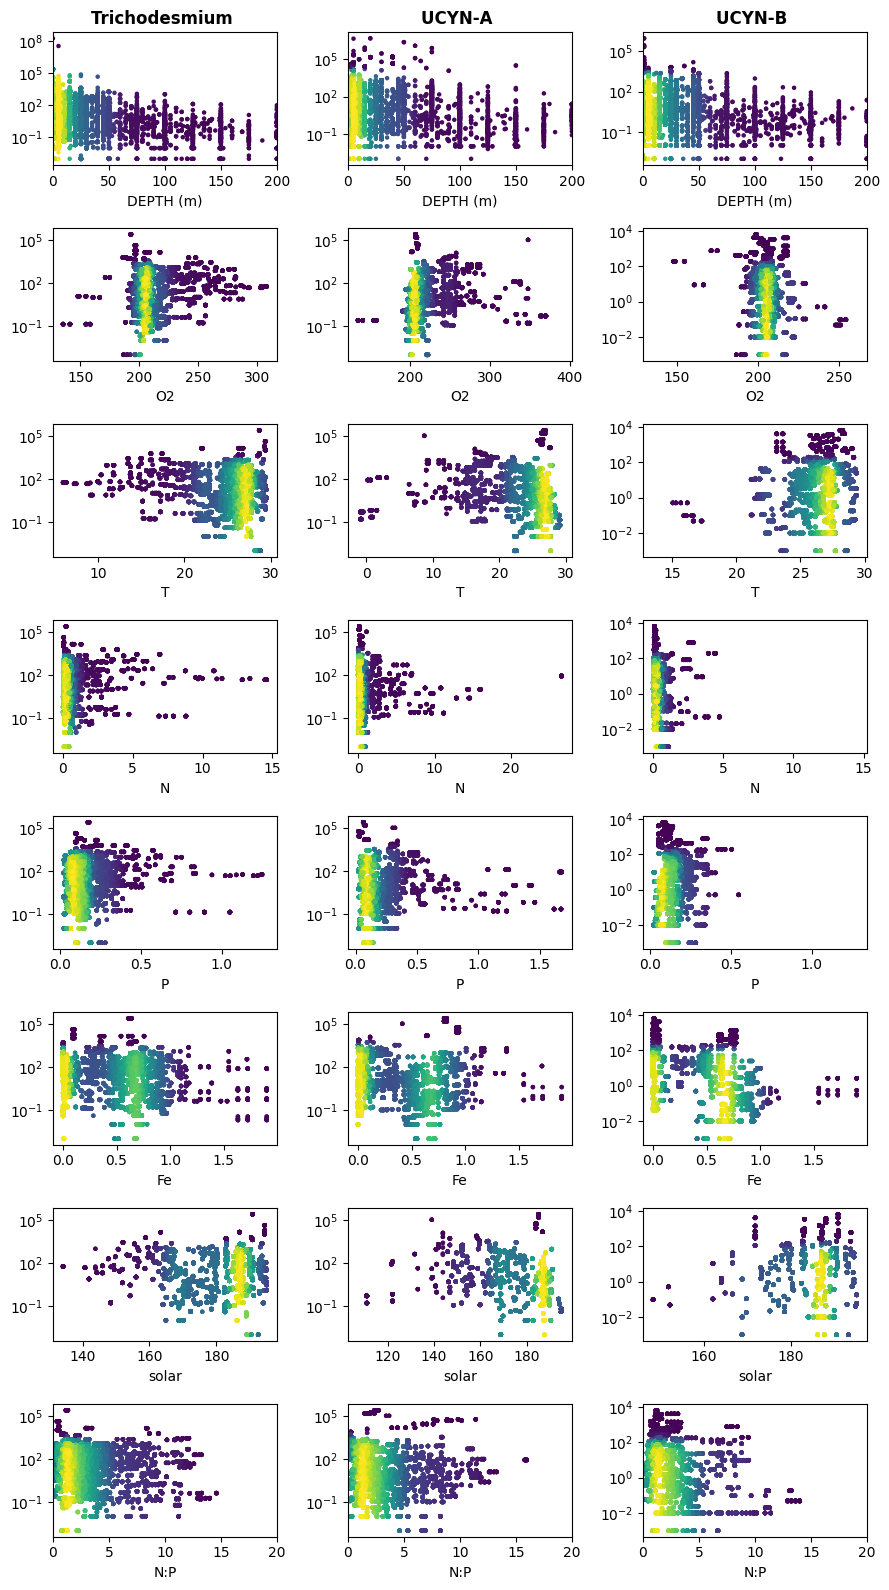

In [14]:
# I initiate the column and row lists for this graph
cols = bact_cols_data_short
cols_count = len(bact_cols_data_short)

rows = ["DEPTH (m)"]+env_cols_data
rows_count = len(rows)

#we need to specify the ranges
x_limits ={
    "DEPTH (m)": (0,200),
    "N:P":(0,20),
}

x_scales = {
    "N": "logit"
}

# Nitrogen should be 0 40 

# Subplots are created
fig, axs = plt.subplots(rows_count, cols_count,figsize=(cols_count*3, rows_count*2))

# Each subplot I create, filter data for null values and specify
for i in range(rows_count):
    for j in range(cols_count):
        x=combined_df[rows[i]].copy()
        y=combined_df[cols[j]].copy()

        # We filter based on the y column to make sure only valid entried are left
        y_null = y.notnull()
        x_null = x.notnull()

        y=y[y_null * x_null]
        x=x[y_null * x_null]

        # Calculate the point density
        xy = np.vstack([x,y])
        z = gaussian_kde(xy)(xy)

        # We create the scatter plot
        ax = axs[i][j]
        ax.scatter(x,y,c=z, s=5)

        # Plot is fit to match
        ax.set(yscale="log")
        ax.set_xlabel(rows[i])
        
        if i==0:
            ax.set_title(cols[j].replace("nifH Gene (x106 copies m-3)",""), fontweight = "bold")

        # Scales are set
        if rows[i] in x_limits:
            ax.set_xlim(x_limits[rows[i]])

        #if rows[i] in x_scales:
        #    ax.set(xscale=x_scales[rows[i]])

plt.tight_layout()
plt.show()
    

## Removing over 50 m depth and updating column list
This is necessary as now we save the data in the exact state it will be used in the training and there should be no null values.

Afterwards we can also save the data into the csv file.

In [15]:
combined_df = filterDepth(combined_df)
combined_df.to_csv("../csv/datasets/nifh_dataset.csv", index=False)

combined_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 30615 entries, 0 to 33105
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   30615 non-null  float64
 1   LONGITUDE                                  30615 non-null  float64
 2   Trichodesmium nifH Gene (x106 copies m-3)  26640 non-null  float64
 3   UCYN-A nifH Gene (x106 copies m-3)         25185 non-null  float64
 4   UCYN-B nifH Gene (x106 copies m-3)         22802 non-null  float64
 5   DEPTH (m)                                  30615 non-null  float64
 6   O2                                         26960 non-null  float64
 7   T                                          26960 non-null  float64
 8   N                                          26960 non-null  float64
 9   P                                          26960 non-null  float64
 10  Fe                         

## Histograms
It is also important to see in what range and how different values are distributed.

### Initial distributions:
We can see that the data is highly skewed 

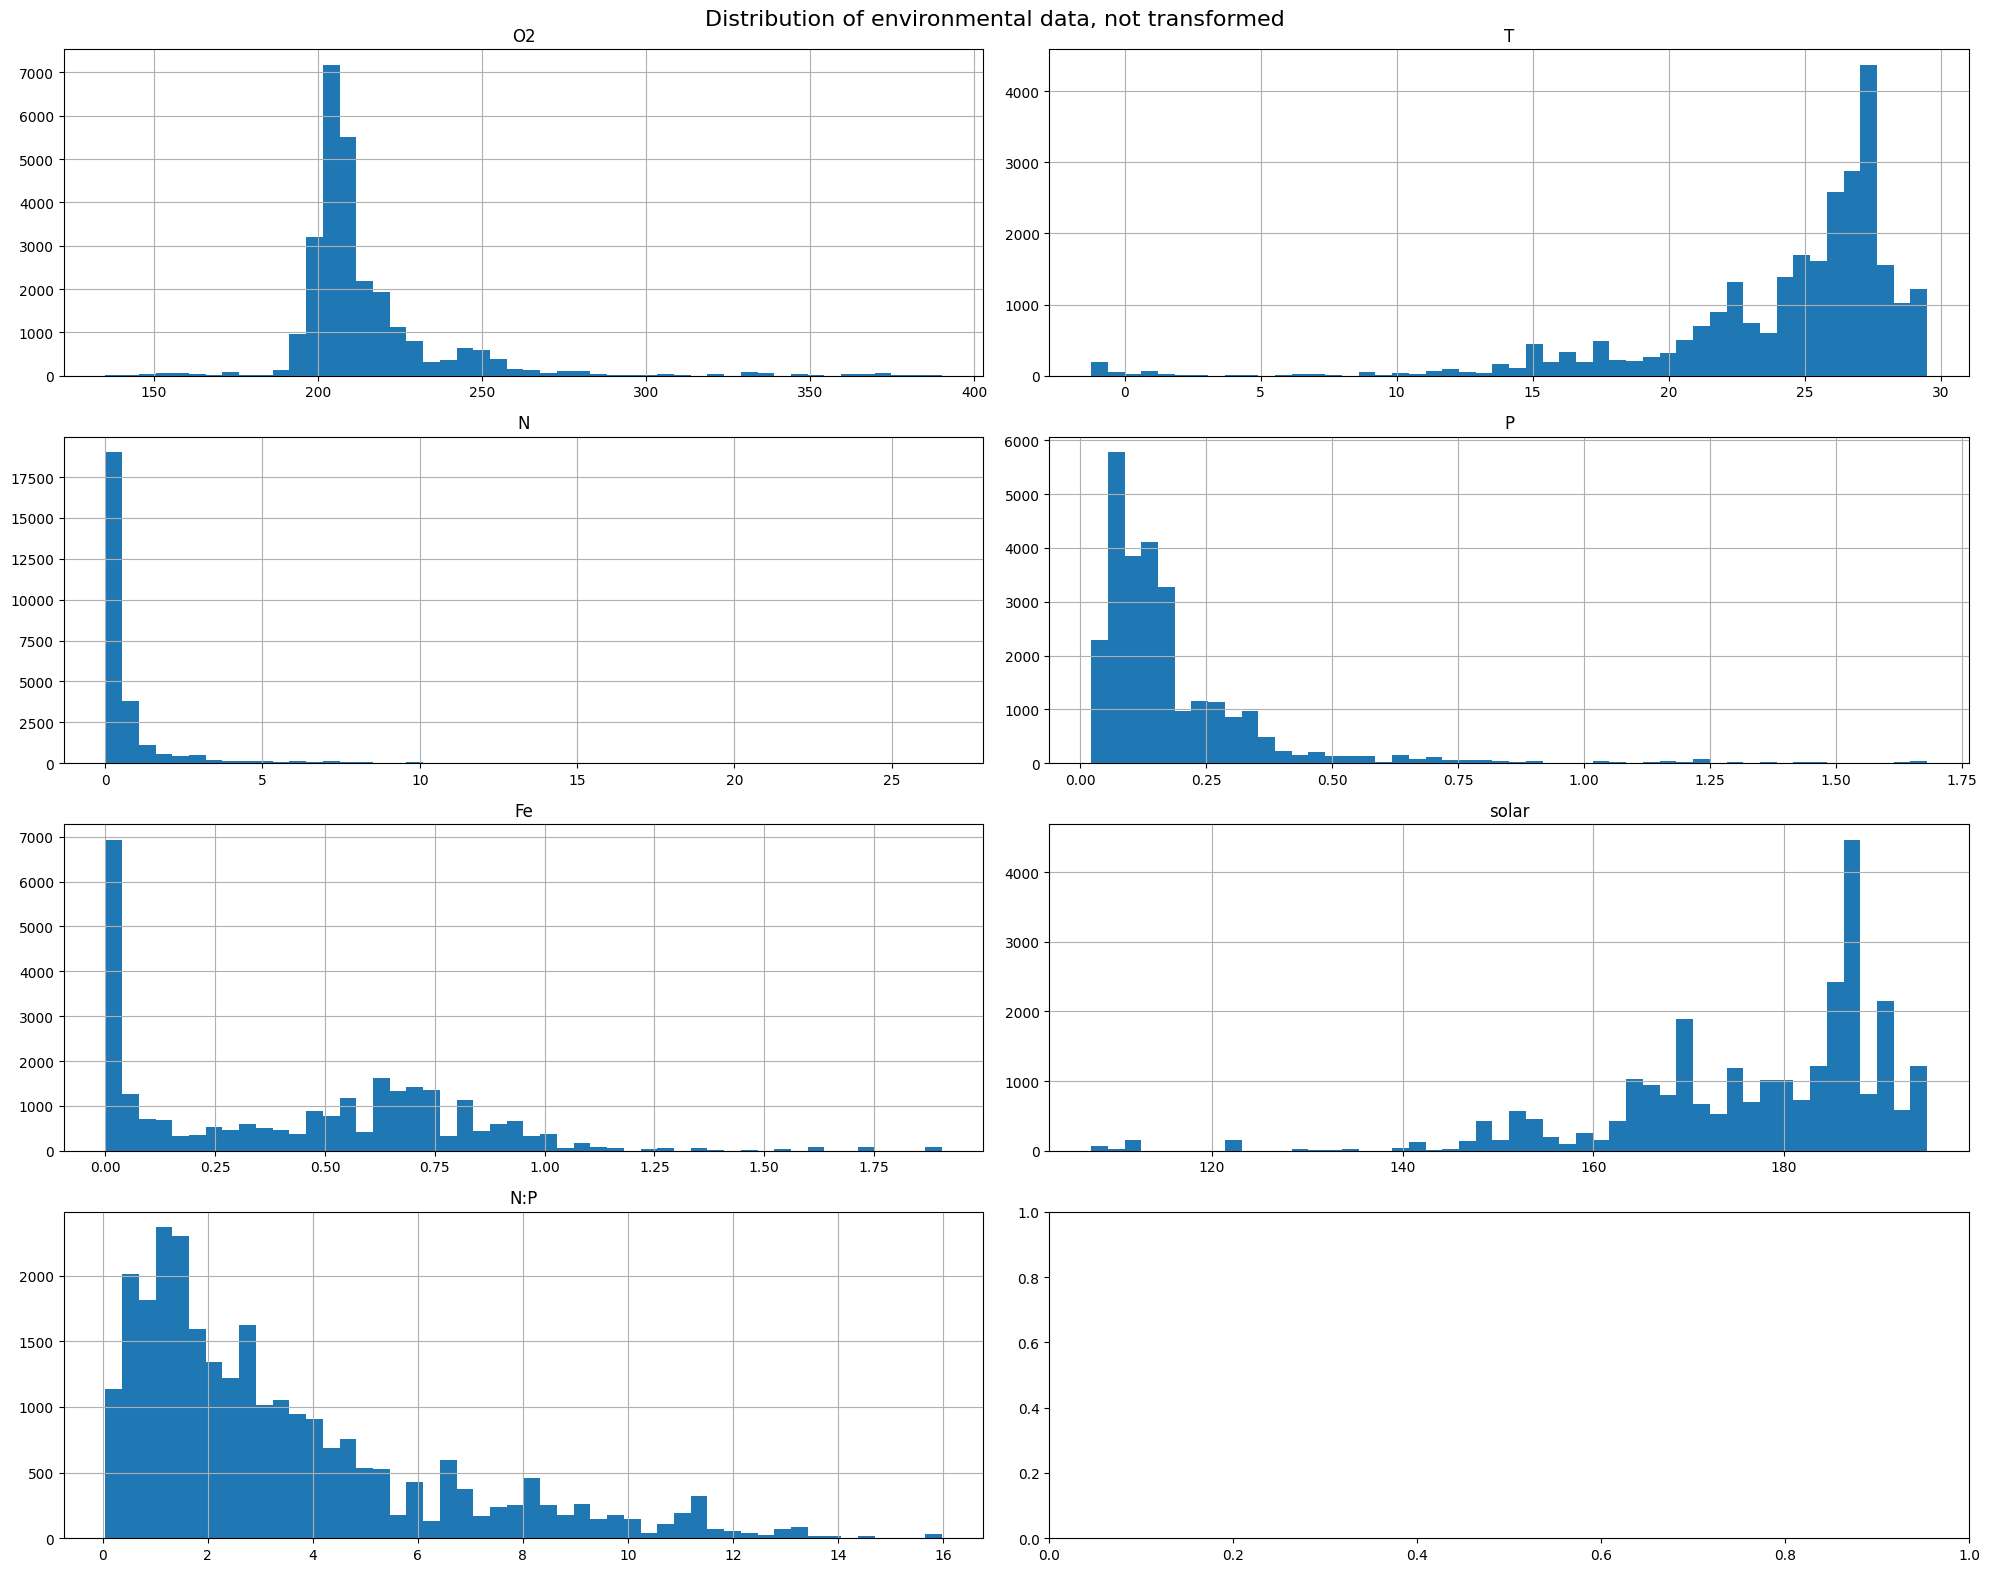

In [16]:
histCols(env_cols_data, combined_df,suptitle="Distribution of environmental data, not transformed")

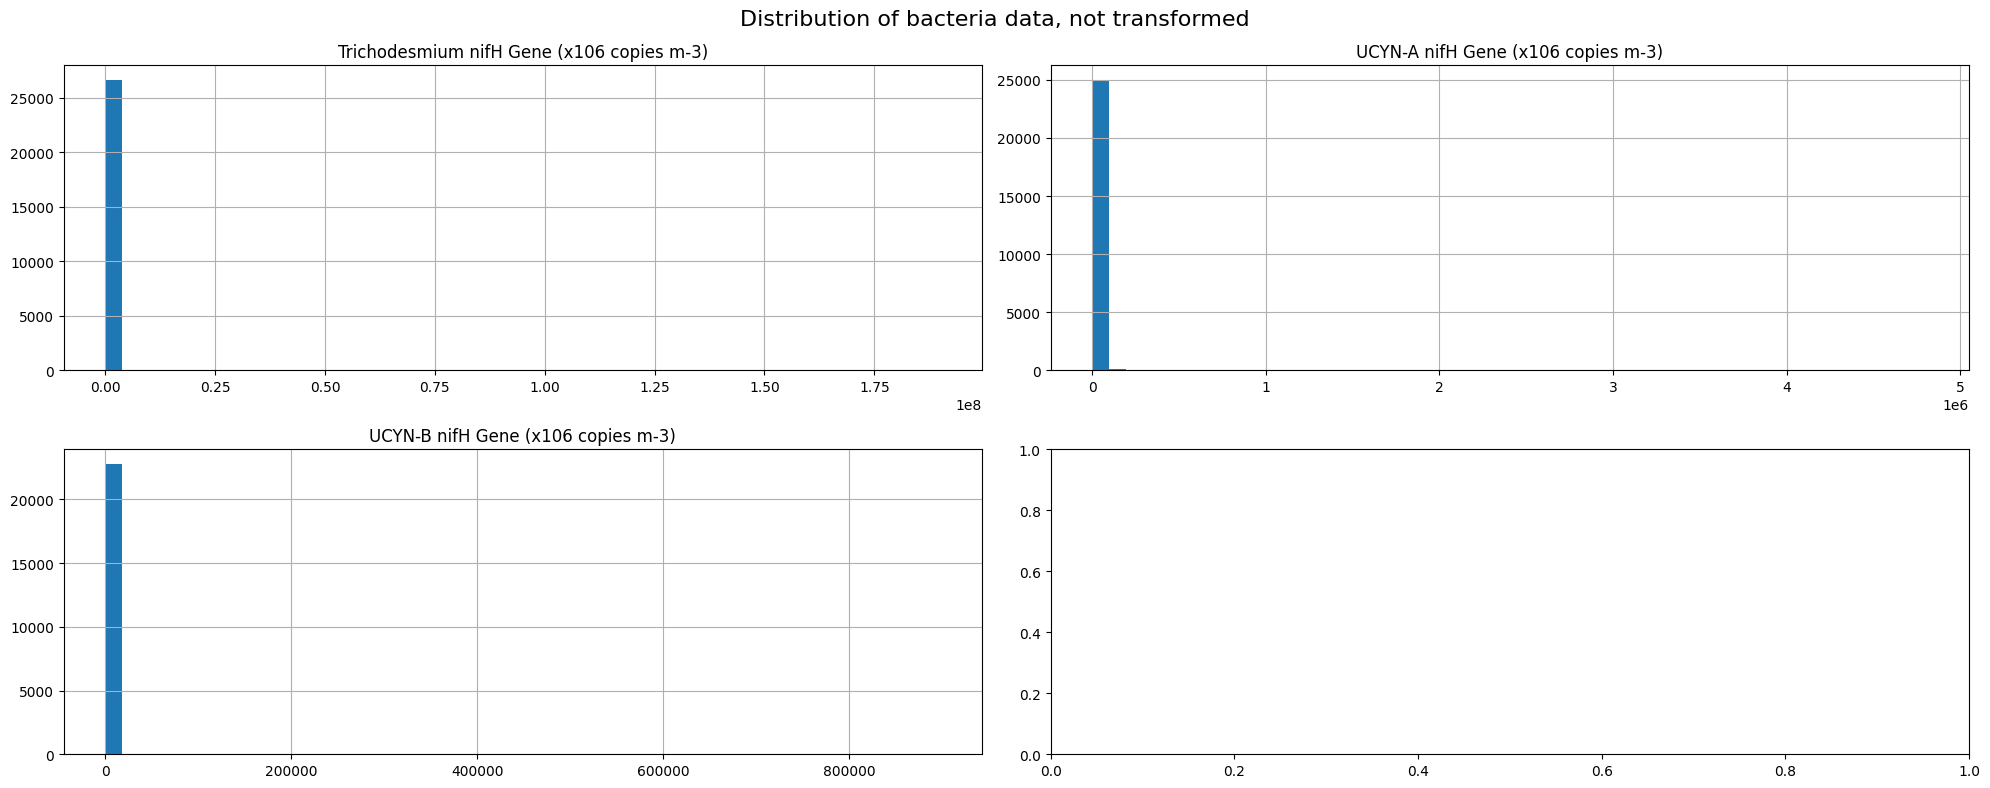

In [17]:
histCols(bact_cols_data, combined_df, suptitle="Distribution of bacteria data, not transformed")

## Correlation matrix
It is also important to see the correlation between different features in the dataset.

Firstly, I plotted the correlation in the initial data. But I also want to see the correlation if we apply the modifications.

We can clearly see that the correlation score significantly increases with the application of the logorithm function and multiplication as it allowed us to get more values in a wider range. But I want to make it even better if possible before training model.

O2                                          -0.044650
T                                            0.047860
N                                           -0.014235
P                                            0.003922
Fe                                           0.003868
solar                                        0.049709
N:P                                         -0.037814
Trichodesmium nifH Gene (x106 copies m-3)    1.000000
UCYN-A nifH Gene (x106 copies m-3)          -0.000303
UCYN-B nifH Gene (x106 copies m-3)          -0.000071
Name: Trichodesmium nifH Gene (x106 copies m-3), dtype: float64


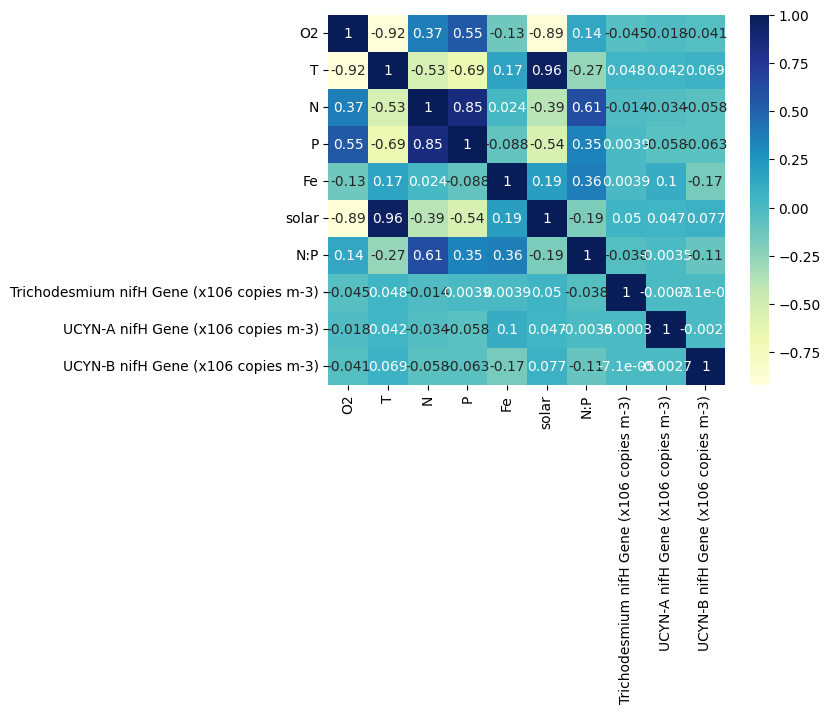

In [18]:
mtrx = combined_df[env_cols_data+bact_cols_data].corr()

print(mtrx["Trichodesmium nifH Gene (x106 copies m-3)"])

sns.heatmap(mtrx, cmap="YlGnBu", annot=True)

plt.show()

## "Outliers"
One of the clear features of all the nifh gene distributions I have noticed is a clear set of values unevenly distributed, which might decrease the performance of the future model and make correlations more difficult to see in the correlation matrix.

One clear way to spot the outliers is to use boxplots. Later discussions resulted in us deciding to keep the remaining outliers as they might represent true data for the rest of the oceans, where nitrogen fixation can be scarce.

Clearly Trichodesmium has an issue of outliers, which can be spotted at the bottom of the boxplot. I want to set the outliers based on the boxplots as NaN, so a row wouldn't be completely lost in case in the other columns the values is valid, but when we want to train the model on a specific.

I used the same method used for boxplots to filter for them(IQR)

In [19]:
from training import setOutliersAsNaNinCols

## Further analysis and transformations
So transformations seem to work, but not uniformly as for some values like Fe the correlation actually decreased. Perhaps we should try applying different formulas to different values as it might produce the best results.

Also, if we want to try out more different formulas there is a need to automate the process and make socring the performance easier.

### More functions

In [20]:
from training import corScore


### Stroing the results
We create a dictionary to store the data of max score for each feature, which with printing outputs should allow us to see the best results and trace them back.

In [21]:
max_scores = dict()
for feat in bact_cols_data_short:
    max_scores[feat]=0.0

In [22]:
transformers = dict()

### Simple transform
Here I applied different transformations for each column, this allows for maximum customization and tuning and also to easily revert back the changes afterwards.

In [23]:
from training import SimpleTransformer

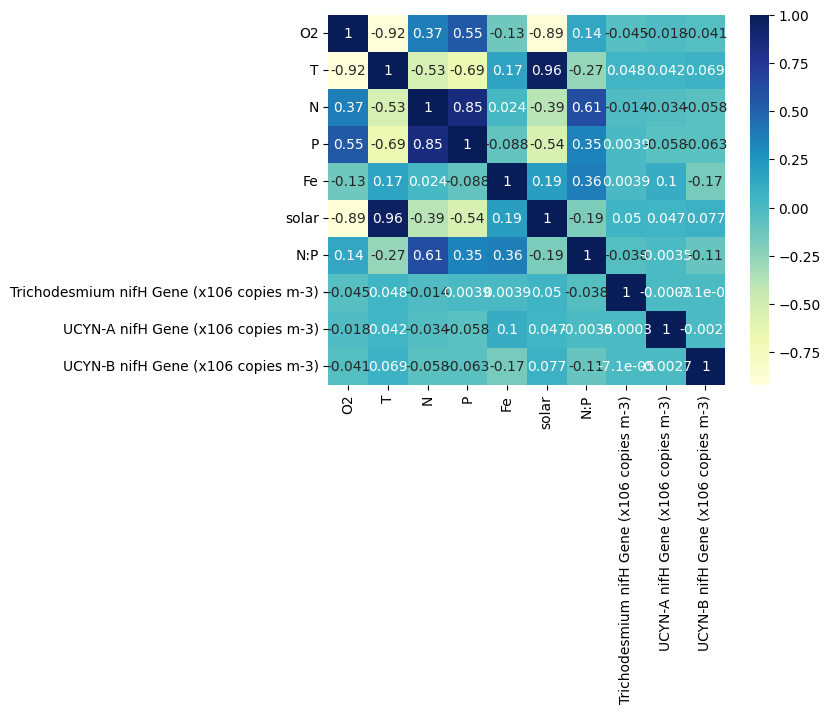

['Trichodesmium nifH Gene (x106 copies m-3)']: correlation mean square average = 0.0012025690744478037
['UCYN-A nifH Gene (x106 copies m-3)']: correlation mean square average = 0.0027663921012040767
['UCYN-B nifH Gene (x106 copies m-3)']: correlation mean square average = 0.008775178659163581

Simple transformer initiated


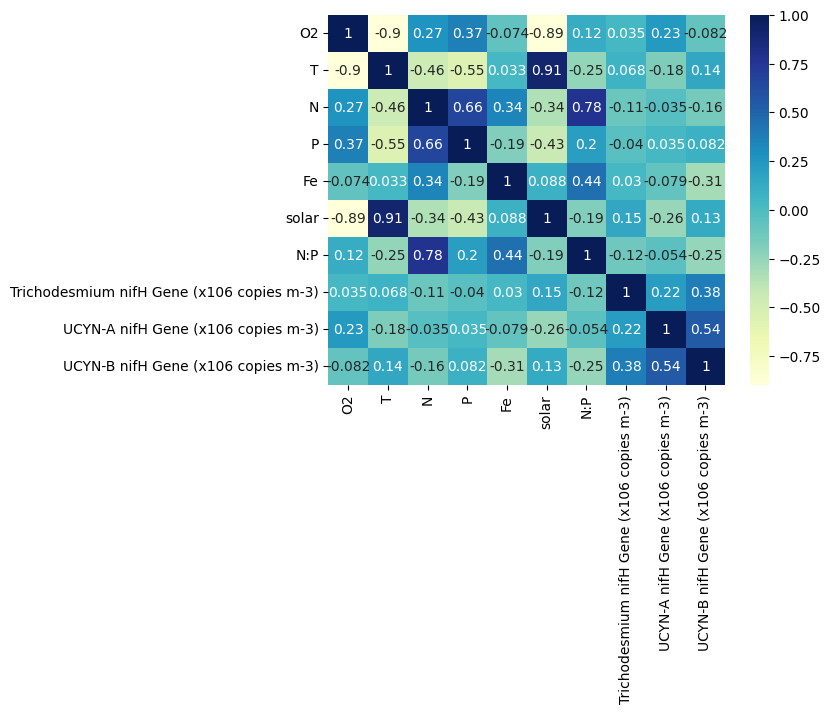

['Trichodesmium nifH Gene (x106 copies m-3)']: correlation mean square average = 0.008419694584252822
['UCYN-A nifH Gene (x106 copies m-3)']: correlation mean square average = 0.024152599434977638
['UCYN-B nifH Gene (x106 copies m-3)']: correlation mean square average = 0.033400253754780895



In [24]:
#we print the inital score
matrx_init = plotCorMatr(env_cols_data+bact_cols_data_short, combined_df)

#this shoes initial correlation score of the matrix
for feat in bact_cols_data_short:
    score = corScore(env_cols_data, [feat], matrx_init)

    #we calculate max
    max_scores[feat]= max(max_scores[feat], score)
print("")

#we create and store the transformer
st = SimpleTransformer()
transformers["simple_transform"]=st

#we apply the transformations
simple_tr_df=st.transform(combined_df.copy())
simple_tr_df.to_csv("../csv/datasets/nifh_dataset_simple_tr.csv", index=False)

#we print the score afterwards
mtrx = plotCorMatr(env_cols_data+bact_cols_data_short, simple_tr_df)
for feat in bact_cols_data_short:
    score = corScore(env_cols_data, [feat], mtrx)

    #we calculate max
    max_scores[feat]= max(max_scores[feat], score)
print("")

In [25]:
simple_tr_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30615 entries, 0 to 33105
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   O2                                         26960 non-null  float64
 1   T                                          26960 non-null  float64
 2   N                                          26960 non-null  float64
 3   P                                          26960 non-null  float64
 4   Fe                                         26960 non-null  float64
 5   solar                                      26960 non-null  float64
 6   N:P                                        26960 non-null  float64
 7   Trichodesmium nifH Gene (x106 copies m-3)  26640 non-null  float64
 8   UCYN-A nifH Gene (x106 copies m-3)         25185 non-null  float64
 9   UCYN-B nifH Gene (x106 copies m-3)         22802 non-null  float64
dtypes: float64(10)
memory usage

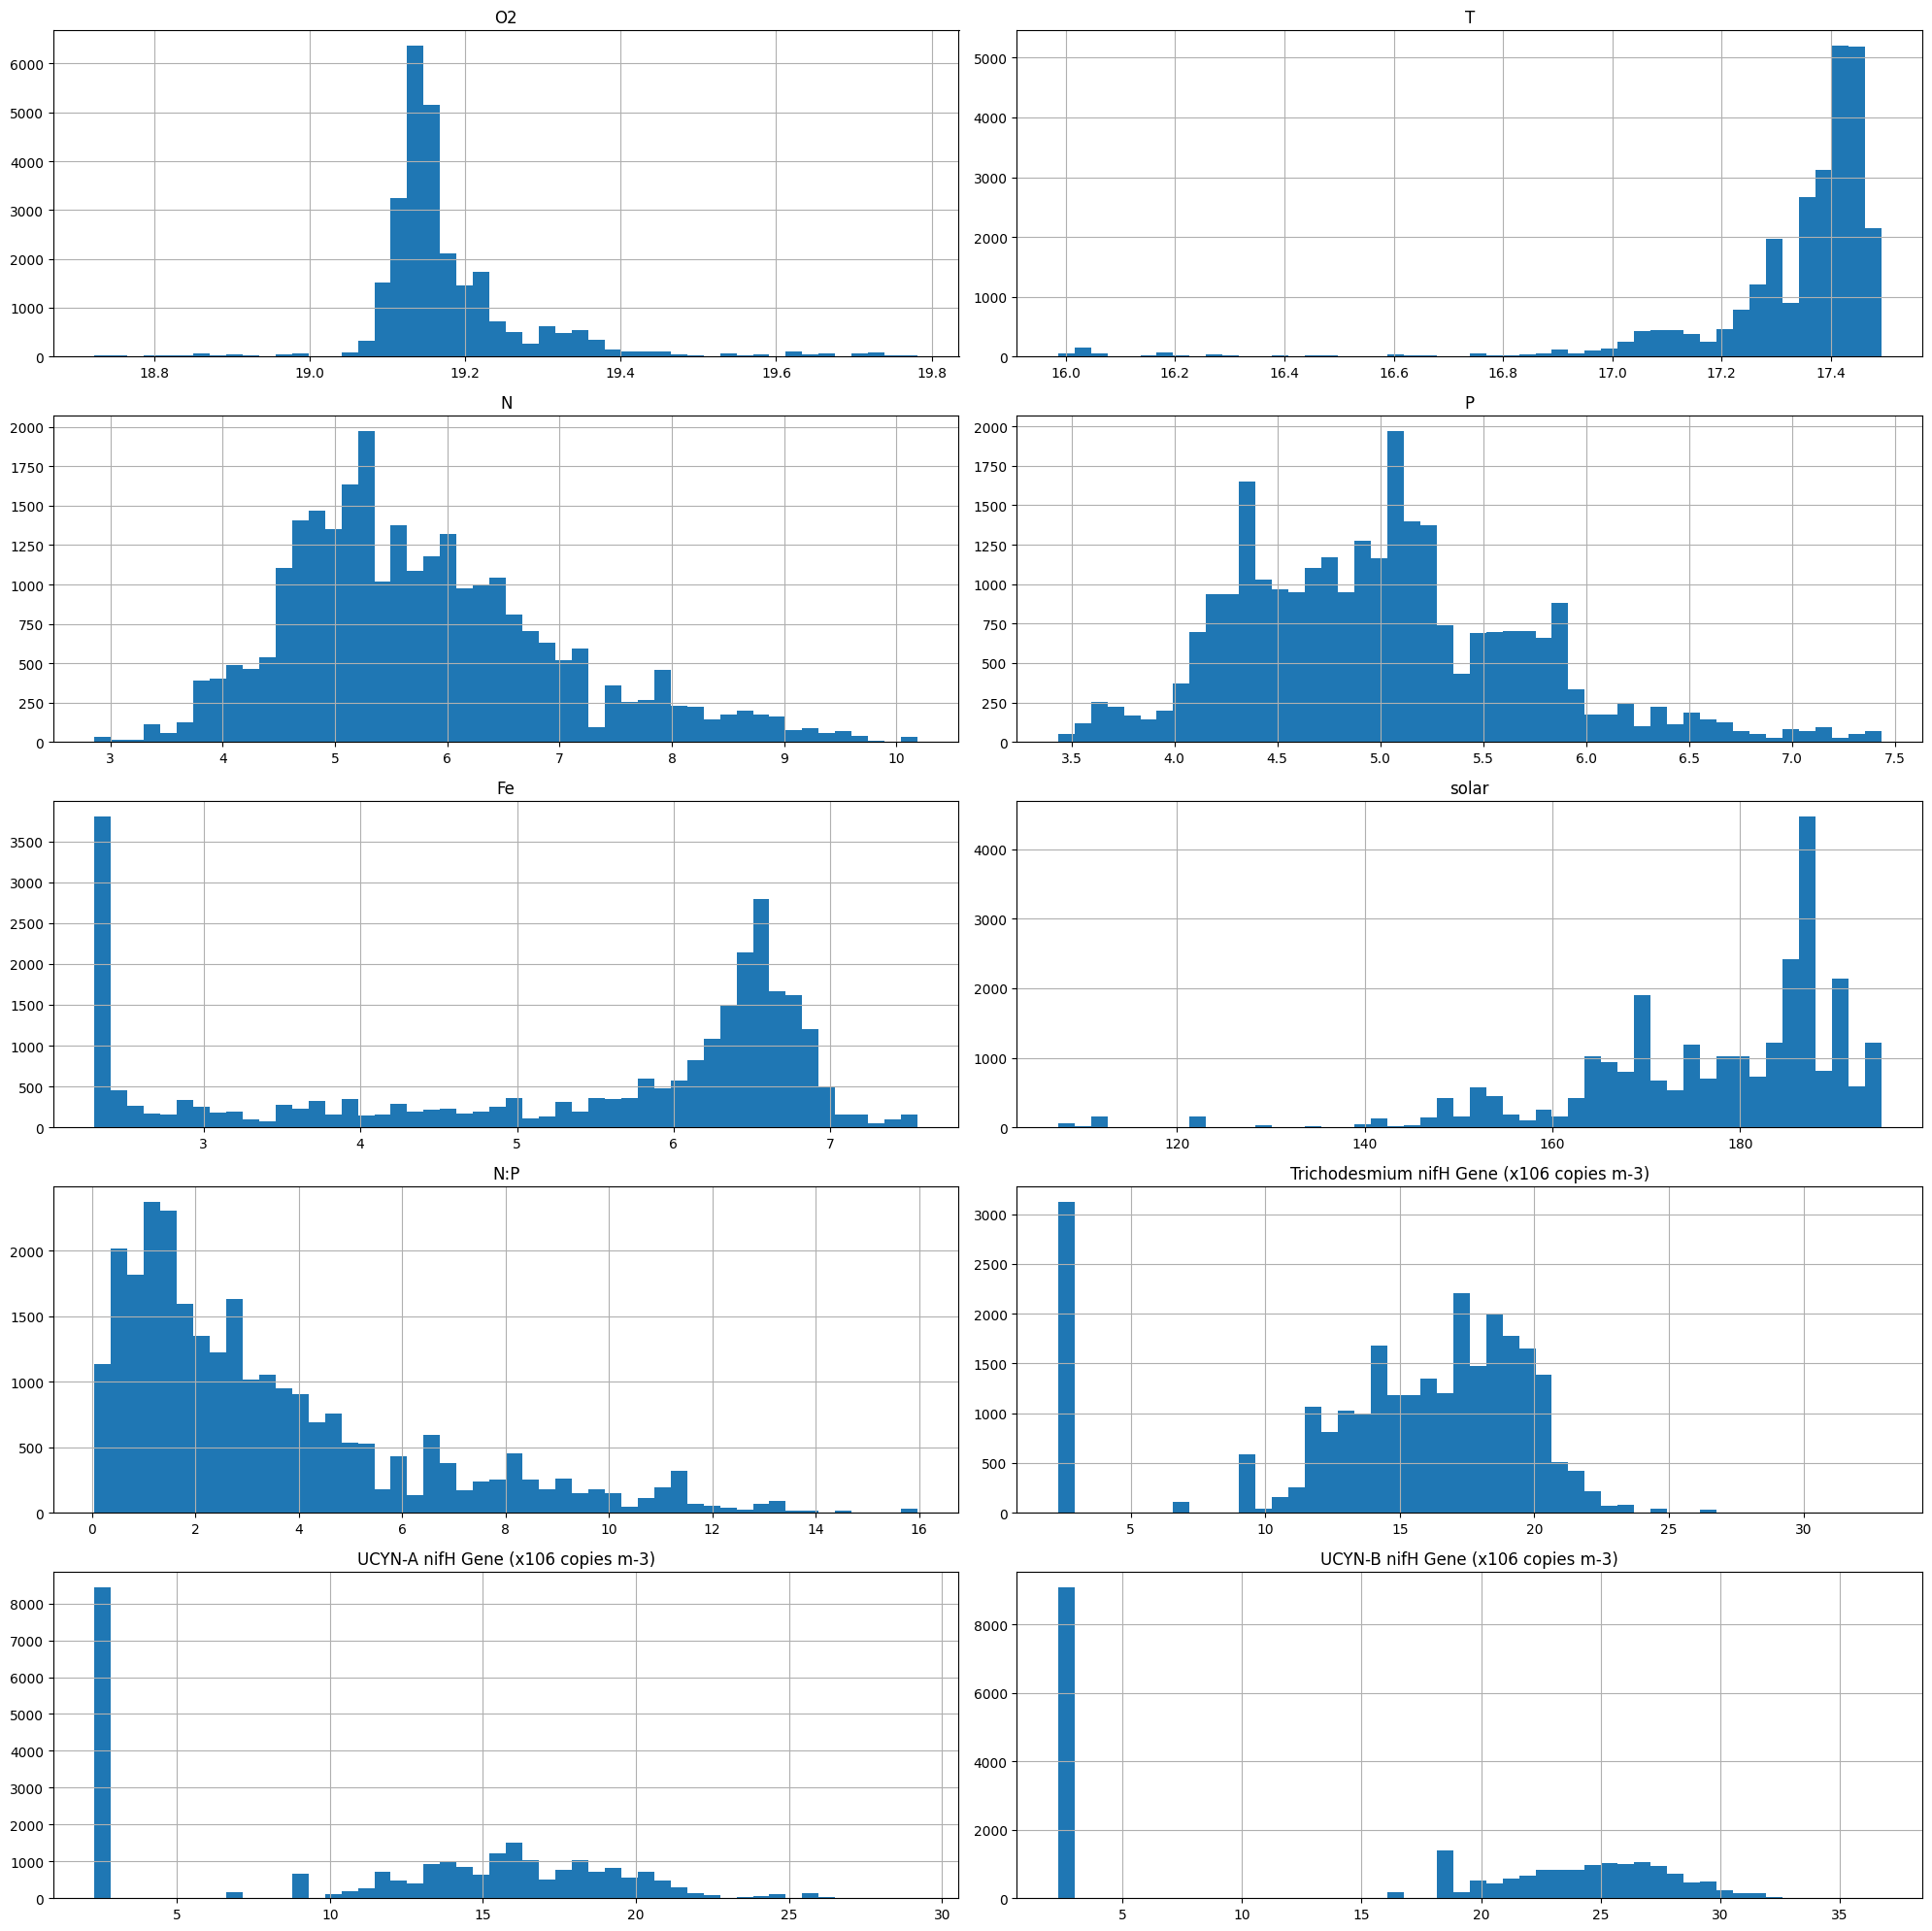

In [26]:
histCols(env_cols_data+bact_cols_data_short, simple_tr_df)

### Simple transform without the bar
The bar on the left of the distribution can be easily removed. Perhaps the model without it can yield better results overall than the others.

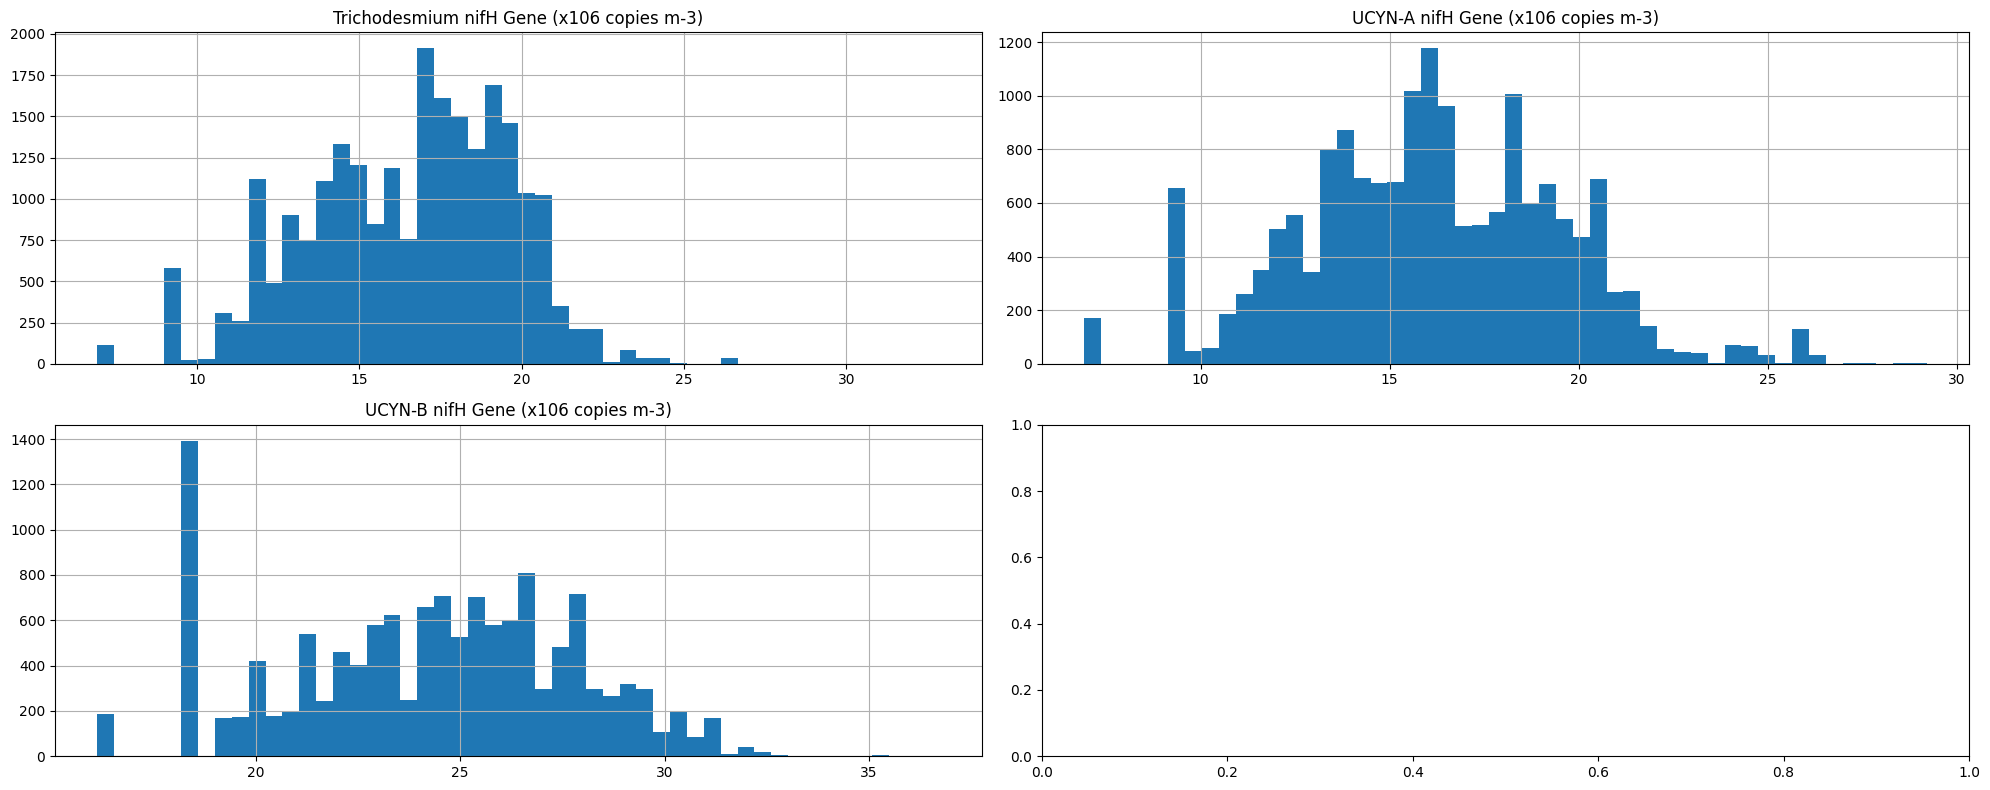

Simple transformer initiated


In [27]:
#combined cp3 is copied over
simple_tr_nobar = simple_tr_df.copy()

for feature in bact_cols_data_short:
    bar_mask = simple_tr_nobar[feature] <= 5
    simple_tr_nobar.loc[bar_mask, feature] = np.nan

histCols(bact_cols_data_short, simple_tr_nobar)
transformers["simple_transform_nobar"]=SimpleTransformer()

simple_tr_nobar.to_csv("../csv/datasets/nifh_dataset_simple_tr_nobar.csv", index=False)

### Outliers
This removes outliers following the same algorithm as is used in displaying boxplots.

In [28]:
#we remove the outliers according to boxplot methods

#TODO NEEDS A FIX LATER ON
''''setOutliersAsNaNinCols(bact_cols_data_short, combined_cp3)

#the results are saved
combined_cp3.to_csv("../csv/datasets/nifh_dataset_simple_tr_out.csv", index=False)

#the results are scored and printed
matrx_out = plotCorMatr(env_cols_data+bact_cols_data_short, combined_cp3)
for feat in bact_cols_data_short:
    score = corScore(env_cols_data, [feat], matrx_out)

    #we calculate max
    max_scores[feat]= max(max_scores[feat], score)'''

'\'setOutliersAsNaNinCols(bact_cols_data_short, combined_cp3)\n\n#the results are saved\ncombined_cp3.to_csv("../csv/datasets/nifh_dataset_simple_tr_out.csv", index=False)\n\n#the results are scored and printed\nmatrx_out = plotCorMatr(env_cols_data+bact_cols_data_short, combined_cp3)\nfor feat in bact_cols_data_short:\n    score = corScore(env_cols_data, [feat], matrx_out)\n\n    #we calculate max\n    max_scores[feat]= max(max_scores[feat], score)'

## second transformer

In [29]:
from training import SecondTransformer

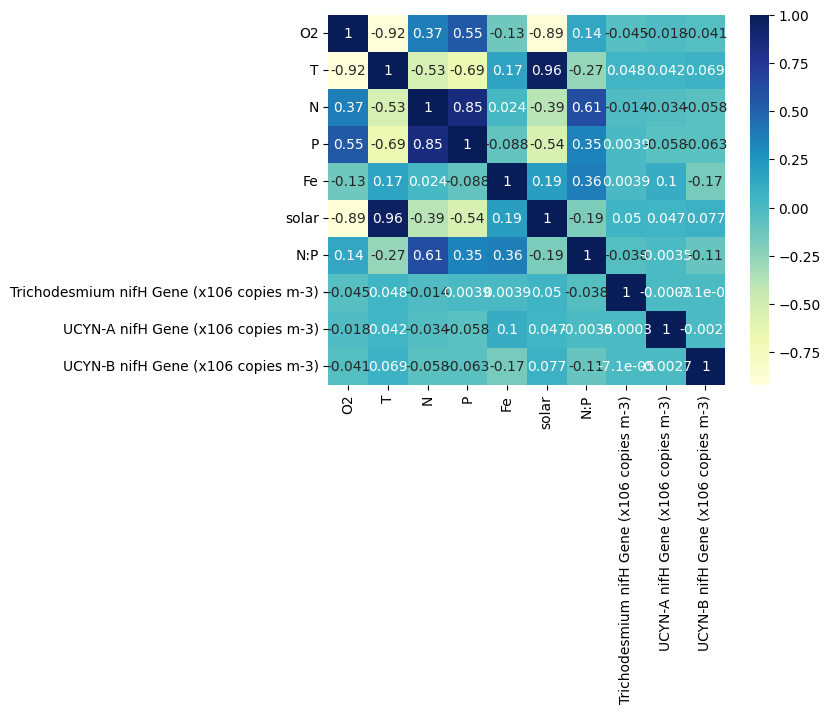

['Trichodesmium nifH Gene (x106 copies m-3)']: correlation mean square average = 0.0012025690744478037
feature: Trichodesmium nifH Gene (x106 copies m-3); score: 0.0012025690744478037
['UCYN-A nifH Gene (x106 copies m-3)']: correlation mean square average = 0.0027663921012040767
feature: UCYN-A nifH Gene (x106 copies m-3); score: 0.0027663921012040767
['UCYN-B nifH Gene (x106 copies m-3)']: correlation mean square average = 0.008775178659163581
feature: UCYN-B nifH Gene (x106 copies m-3); score: 0.008775178659163581

Second transformer initiated


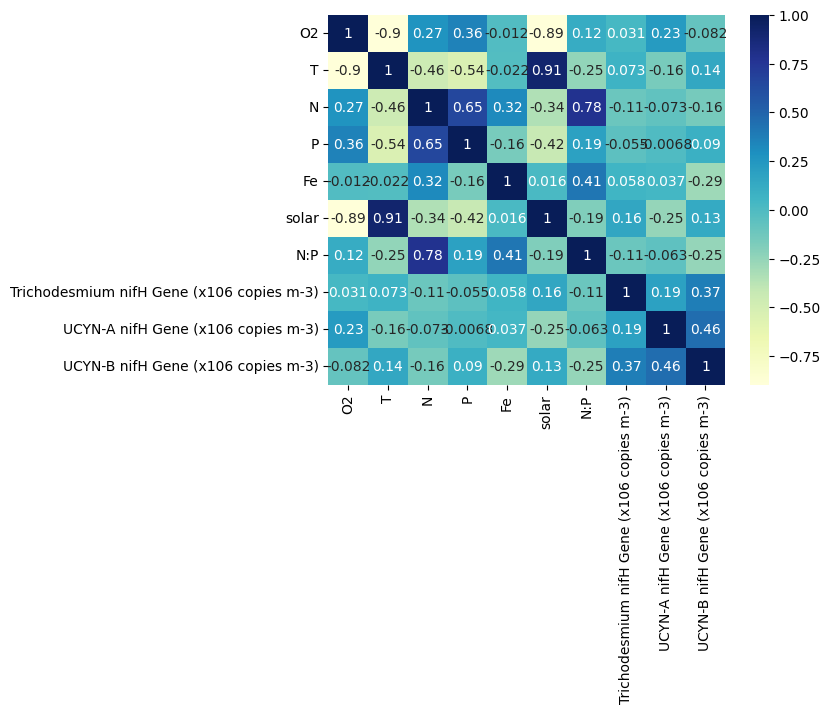

['Trichodesmium nifH Gene (x106 copies m-3)']: correlation mean square average = 0.008668846962144294
feature: Trichodesmium nifH Gene (x106 copies m-3); score: 0.008668846962144294
['UCYN-A nifH Gene (x106 copies m-3)']: correlation mean square average = 0.021724328193381874
feature: UCYN-A nifH Gene (x106 copies m-3); score: 0.021724328193381874
['UCYN-B nifH Gene (x106 copies m-3)']: correlation mean square average = 0.03176663444569018
feature: UCYN-B nifH Gene (x106 copies m-3); score: 0.03176663444569018



In [30]:
#we print the inital score
matrx_init = plotCorMatr(env_cols_data+bact_cols_data_short, combined_df)

#this shoes initial correlation score of the matrix
for feat in bact_cols_data_short:
    score = corScore(env_cols_data, [feat], matrx_init)
    print("feature: {0}; score: {1}".format(feat, score))
print("")

#we create and store the transformer
sndt = SecondTransformer()
transformers["second_transform"]=sndt

#we apply the transformations
second_tr_df=sndt.transform(combined_df.copy())
second_tr_df.to_csv("../csv/datasets/nifh_dataset_second_tr.csv", index=False)

#we print the score afterwards
mtrx = plotCorMatr(env_cols_data+bact_cols_data_short, second_tr_df)
for feat in bact_cols_data_short:
    score = corScore(env_cols_data, [feat], mtrx)
    print("feature: {0}; score: {1}".format(feat, score))
print("")

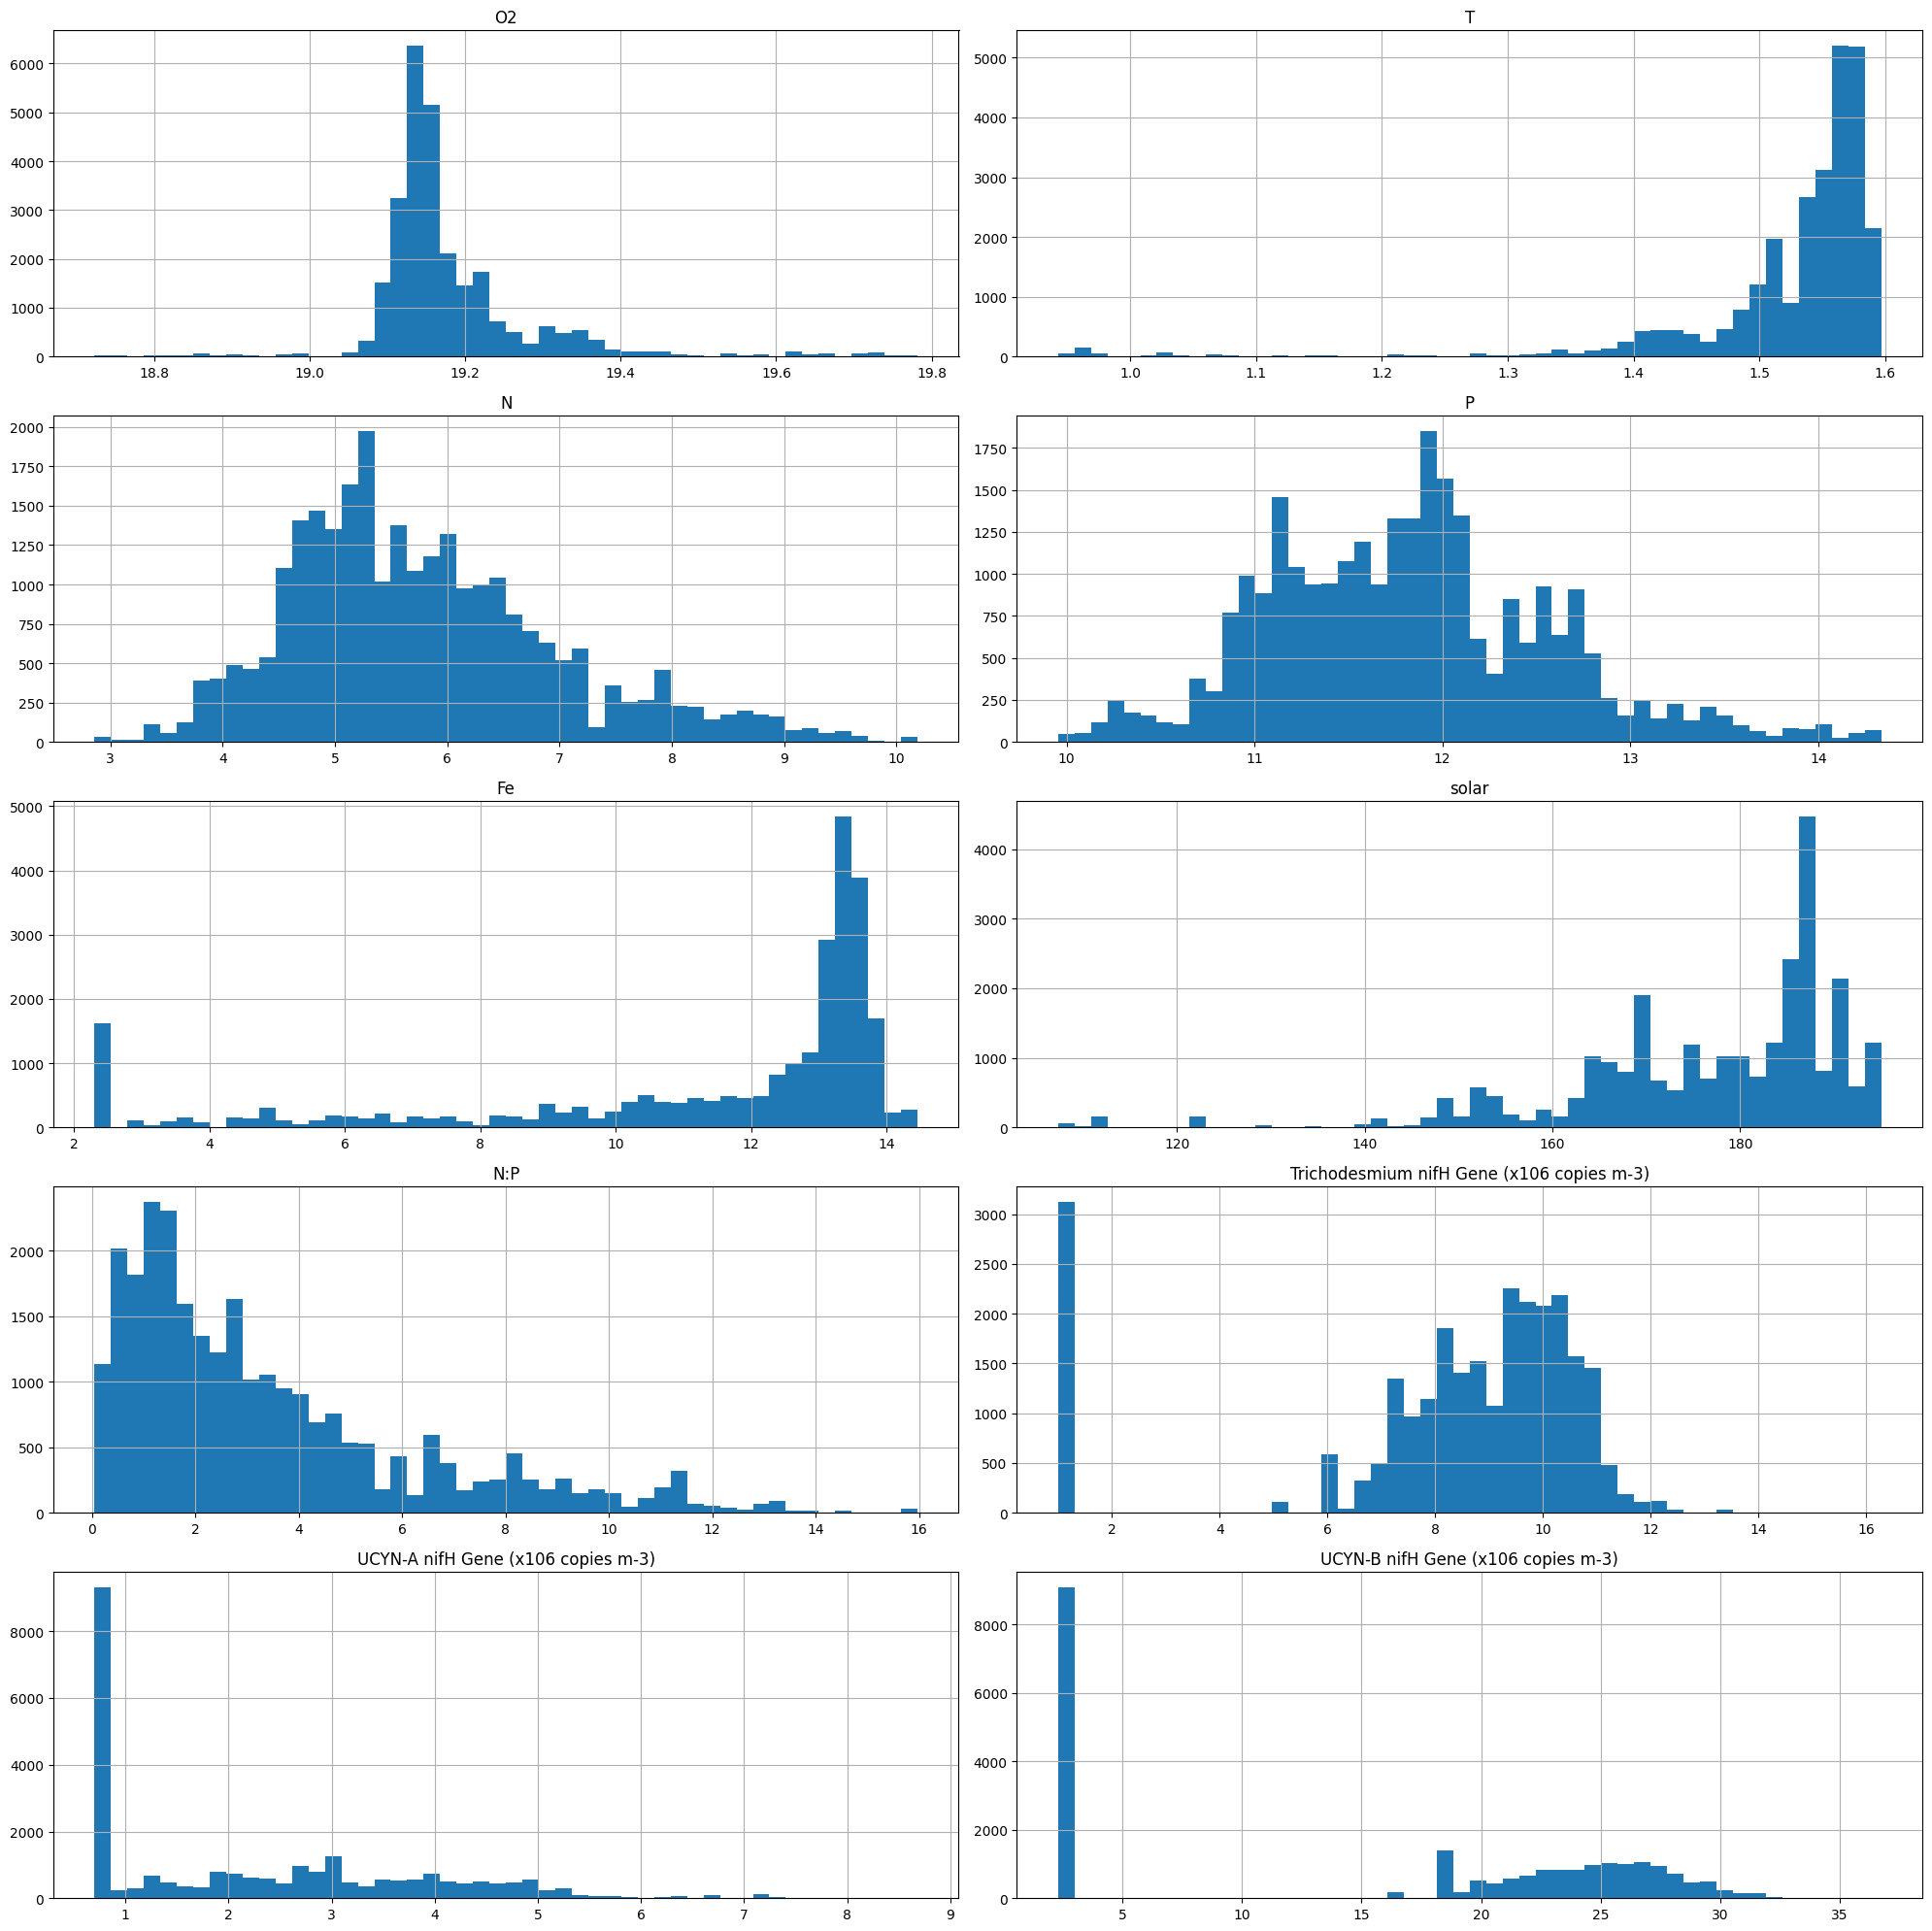

In [31]:
histCols(env_cols_data+bact_cols_data_short, second_tr_df)

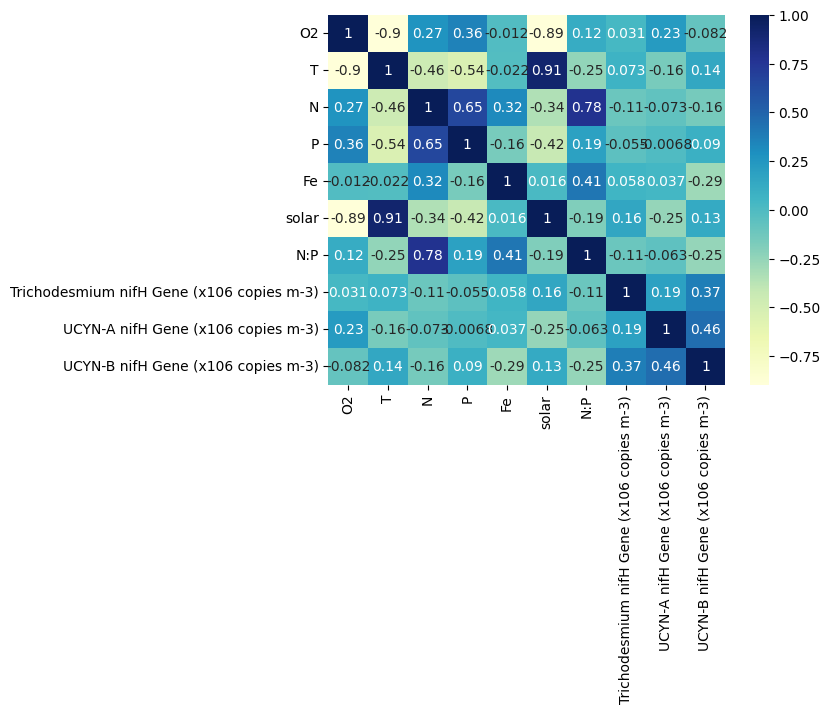

,O2,T,N,P,Fe,solar,N:P,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
O2,1.000000,-0.896758,0.271713,0.358749,-0.011901,-0.889768,0.116423,0.031283,0.226701,-0.082107
T,-0.896758,1.000000,-0.455548,-0.537137,-0.021846,0.911843,-0.245233,0.073369,-0.158247,0.144249
N,0.271713,-0.455548,1.000000,0.653894,0.320644,-0.341271,0.784479,-0.108499,-0.072511,-0.155534
P,0.358749,-0.537137,0.653894,1.000000,-0.159458,-0.422609,0.187129,-0.055445,-0.006795,0.090490
Fe,-0.011901,-0.021846,0.320644,-0.159458,1.000000,0.015554,0.409599,0.058261,0.037320,-0.286572
solar,-0.889768,0.911843,-0.341271,-0.422609,0.015554,1.000000,-0.187117,0.155051,-0.254793,0.127424
N:P,0.116423,-0.245233,0.784479,0.187129,0.409599,-0.187117,1.000000,-0.109723,-0.063392,-0.253135
Trichodesmium nifH Gene (x106 copies m-3),0.031283,0.073369,-0.108499,-0.055445,0.058261,0.155051,-0.109723,1.000000,0.188498,0.372775
UCYN-A nifH Gene (x106 copies m-3),0.226701,-0.158247,-0.072511,-0.006795,0.037320,-0.254793,-0.063392,0.188498,1.000000,0.458264
UCYN-B nifH Gene (x106 copies m-3),-0.082107,0.144249,-0.155534,0.090490,-0.286572,0.127424,-0.253135,0.372775,0.458264,1.000000


In [32]:
from sklearn.preprocessing import StandardScaler

# I don't think this sections contributes much and maybe should be removed
stsclr = StandardScaler()
combined_sndt_scld = pd.DataFrame(
        stsclr.fit_transform(second_tr_df),
        columns=second_tr_df.columns,
        index=second_tr_df.index
    )

transformers["second_transform_scaler"]=stsclr
combined_sndt_scld.to_csv("../csv/datasets/nifh_dataset_second_tr_scaled.csv", index=False)

plotCorMatr(env_cols_data+bact_cols_data_short, combined_sndt_scld)

## Using sci kit learn scalers
Sci kit learn provides a methods for transforming distributions in a more automated manner. It is tried in the section below. However, seemingly the results are not better, than what I could achieve. 

Also, I tried using different scalers to test how they affect the performance of the score.

In [33]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from scipy import stats

#saving the results
sci_kit_transformed = dict()

#we store the scalers into an array to easily go through them
pt0 = PowerTransformer()
pt = PowerTransformer(method='box-cox')
qt = QuantileTransformer(n_quantiles=10, random_state=0, output_distribution='normal')
mnmx = MinMaxScaler()
stdsclr = StandardScaler()
yj = PowerTransformer(method='yeo-johnson')

scalers = [pt,pt0,qt, mnmx,stdsclr, yj]
scalers_names =["PowerTransformer: box-cox","PowerTransformer", "QuantileTransformer", "MinMaxScaler", "StandardScaler", "PowerTransformer: yeo-johnson"]

#we create the dataframe for this tr
combined_scikit = combined_df[env_cols_data+bact_cols_data_short].copy()
combined_scikit= combined_scikit+3#we need positive values

#we print results for each scaler
for i, scaler in enumerate(scalers):
    #we create the transformed dataframe
    combined_scikit_tr = pd.DataFrame(
        scaler.fit_transform(combined_scikit),
        columns=combined_scikit.columns,
        index=combined_scikit.index
    )

    sci_kit_transformed[scalers_names[i]] = combined_scikit_tr

    #best scores are saved here into files
    if(i==1 or i==2):
        transformer_name = "power_transf" if (i==1) else "quantile_transf"
        combined_scikit_tr.to_csv("../csv/datasets/nifh_dataset_"+transformer_name+".csv", index=False)
        transformers[transformer_name]=scaler

    #correlation matrix is created
    mtrx = combined_scikit_tr.corr()

    #the results are printed and scored for each feature
    print(scalers_names[i])
    for feat in bact_cols_data_short:
        score = corScore(env_cols_data, [feat], mtrx)
        mean = np.mean(combined_scikit_tr[feat])
        median = np.median(combined_scikit_tr[feat].dropna())
        mode = stats.mode(combined_scikit_tr[feat].dropna())

        print("feature: {0}, mean: {1}, median: {2}, mode: {3}".format(feat, mean, median, mode.mode))

        #we calculate max
        max_scores[feat]= max(max_scores[feat], score)
    print("")

#the max cor coefficients are printed
for feat in bact_cols_data_short:
    print("feature: {0}, max_score: {1}".format(feat, max_scores[feat]))

PowerTransformer: box-cox
['Trichodesmium nifH Gene (x106 copies m-3)']: correlation mean square average = 0.010736706720581881
feature: Trichodesmium nifH Gene (x106 copies m-3), mean: -5.1210287261989203e-17, median: -0.11770470489032883, mode: -1.1686325652297833
['UCYN-A nifH Gene (x106 copies m-3)']: correlation mean square average = 0.045494060377071266
feature: UCYN-A nifH Gene (x106 copies m-3), mean: -2.708441637203479e-16, median: -0.5470245563841427, mode: -0.8866380764171823
['UCYN-B nifH Gene (x106 copies m-3)']: correlation mean square average = 0.05239209599605264
feature: UCYN-B nifH Gene (x106 copies m-3), mean: -5.284977106609639e-16, median: -0.7339887073769025, mode: -0.773066953420226

PowerTransformer
['Trichodesmium nifH Gene (x106 copies m-3)']: correlation mean square average = 0.010470462612048386
feature: Trichodesmium nifH Gene (x106 copies m-3), mean: -5.1210287261989203e-17, median: -0.15332027425106837, mode: -1.1433857067076882
['UCYN-A nifH Gene (x106 c

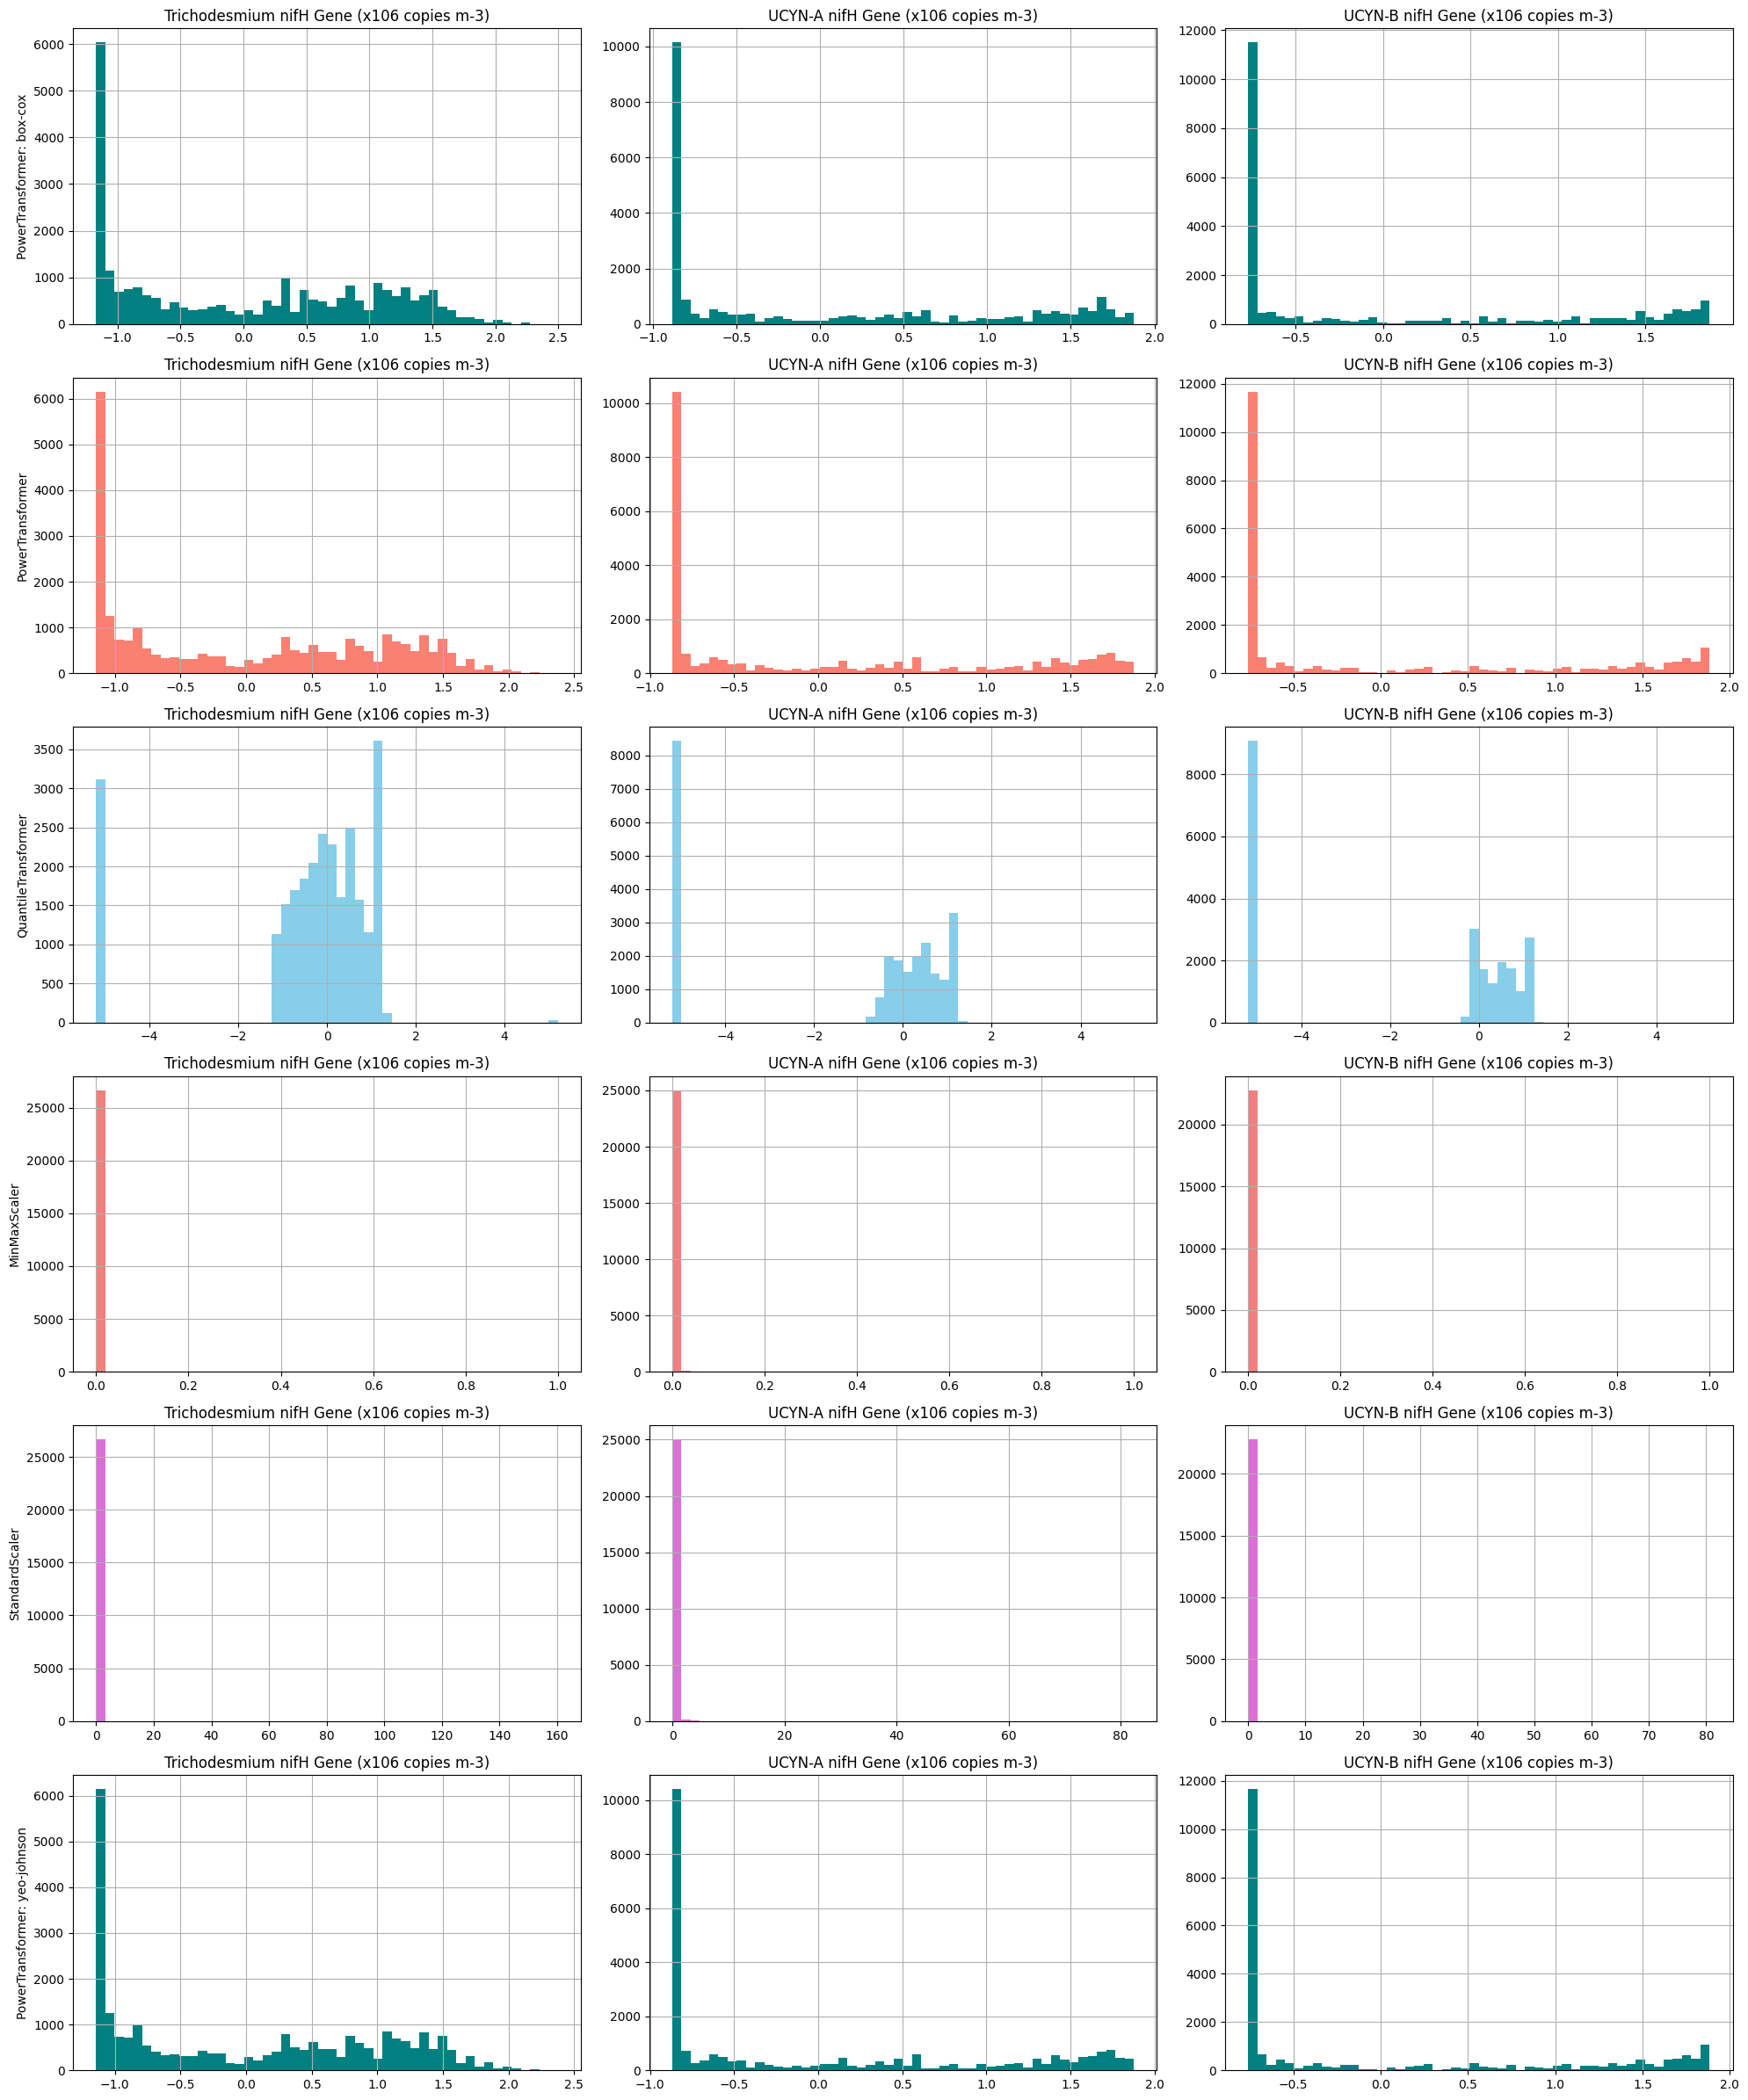

In [34]:
#a set of subplots is created
fig, axes = plt.subplots(nrows=len(scalers_names), ncols=3, figsize=(20, len(scalers_names)*4))

#we plot each column
axes = axes.flatten()
colors = ["teal", "salmon", "skyblue", "lightcoral", "orchid"]
i = 0   

for tr_name, dataset in sci_kit_transformed.items():
    color = colors[(i//3)%len(colors)]
    for feature in bact_cols_data_short:
        ax = axes[i]#subplot
        if i%3==0:
            ax.set_ylabel(tr_name)
        valid_data = dataset[feature].dropna()
        valid_data.hist(bins=50, ax=ax, color=color)
        ax.set_title(feature)
        i+=1

plt.tight_layout()
plt.show()


### Results
Custom transformation seems to work very well on Trichodesmium data, but the results for UCYN bacteria are sigificatnly better when a scaler is applied. For A ir is box cox transformation that yields the best results, while for the B it is Quantile transformer.

In [35]:
joblib.dump(transformers, "../model/transformers")

['../model/transformers']